<a href="https://colab.research.google.com/github/Sazid669/Optimization_robotics/blob/IFRoS-Master/problem_setting_cem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

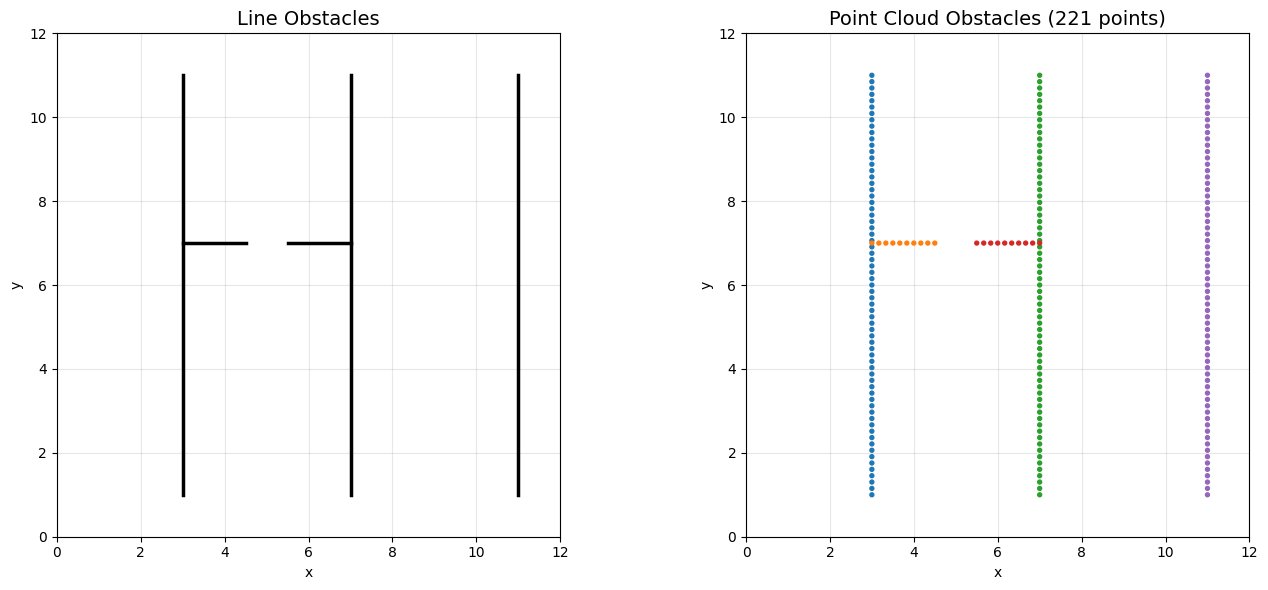

Total point obstacles: 221

Point cloud shape: (221, 2)
Sample points (first 10):
[[ 3.         11.        ]
 [ 3.         10.84848485]
 [ 3.         10.6969697 ]
 [ 3.         10.54545455]
 [ 3.         10.39393939]
 [ 3.         10.24242424]
 [ 3.         10.09090909]
 [ 3.          9.93939394]
 [ 3.          9.78787879]
 [ 3.          9.63636364]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def line_to_points(start, end, spacing=0.1):
    """Convert a line segment to a set of point obstacles."""
    start = np.array(start, dtype=float)
    end = np.array(end, dtype=float)
    length = np.linalg.norm(end - start)
    n_points = max(int(np.ceil(length / spacing)), 2)
    t = np.linspace(0, 1, n_points)
    points = np.column_stack([
        start[0] + t * (end[0] - start[0]),
        start[1] + t * (end[1] - start[1])
    ])
    return points


def create_workspace_obstacles(spacing=0.1):
    """
    Define line obstacles based on the uploaded image.

    The image shows (approximately):
      - Two vertical lines (like walls)
      - Two horizontal stubs extending from the verticals (like T-junctions)
      - One vertical line on the right side

    Mapped to a [-6, 6] x [-6, 6] workspace.
    """
    line_segments = [
        # Left vertical wall
        ((3, 11), (3, 1)),
        # Left horizontal stub (extends right from left wall)
        ((3, 7), (4.5, 7)),

        # Middle vertical wall
        ((7, 11), (7, 1)),
        # Middle horizontal stub (extends left from middle wall)
        ((5.5, 7), (7, 7)),

        # Right vertical wall
        ((11, 11), (11, 1)),
    ]

    all_points = []
    segment_labels = []

    for i, (start, end) in enumerate(line_segments):
        pts = line_to_points(start, end, spacing=spacing)
        all_points.append(pts)
        segment_labels.extend([i] * len(pts))

    point_cloud = np.vstack(all_points)
    segment_labels = np.array(segment_labels)

    return point_cloud, segment_labels, line_segments


def plot_workspace(point_cloud, segment_labels, line_segments):
    """Visualize the workspace with point obstacles."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --- Left plot: original line obstacles ---
    ax = axes[0]
    ax.set_title("Line Obstacles", fontsize=14)
    for start, end in line_segments:
        ax.plot([start[0], end[0]], [start[1], end[1]], 'k-', linewidth=2.5)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    # --- Right plot: point cloud representation ---
    ax = axes[1]
    ax.set_title(f"Point Cloud Obstacles ({len(point_cloud)} points)", fontsize=14)
    colors = plt.cm.tab10(segment_labels % 10)
    ax.scatter(point_cloud[:, 0], point_cloud[:, 1], c=colors, s=8, zorder=2)
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 12)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    plt.tight_layout()
    plt.savefig("obstacle_point_cloud.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Total point obstacles: {len(point_cloud)}")


if __name__ == "__main__":
    # Spacing between consecutive point obstacles (smaller = denser cloud)
    SPACING = 0.15

    point_cloud, labels, segments = create_workspace_obstacles(spacing=SPACING)
    plot_workspace(point_cloud, labels, segments)

    # Export for use in other modules
    # np.save("obstacle_points.npy", point_cloud)
    print("\nPoint cloud shape:", point_cloud.shape)
    print("Sample points (first 10):")
    print(point_cloud[:10])

# Problem 1


## Unicycle

Weighted CEM parameters initialized.


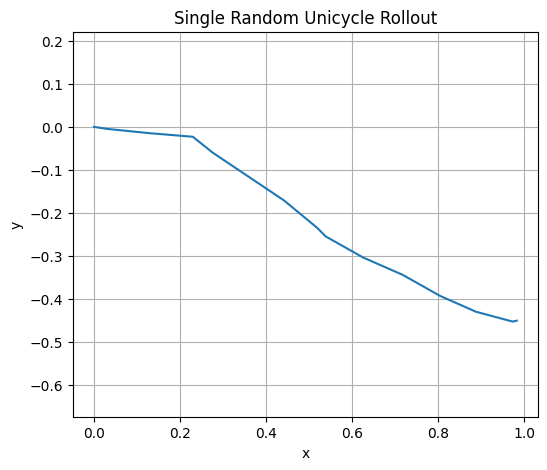

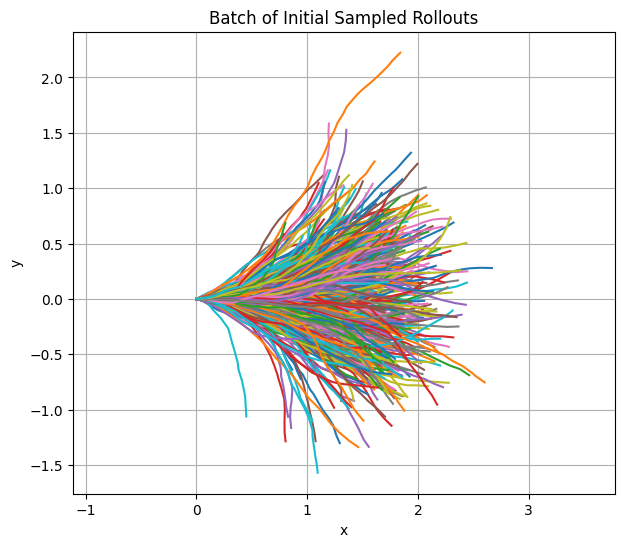

iter=01, best_cost=2108.4539, elite_mean_cost=2523.9287
iter=10, best_cost=1201.5967, elite_mean_cost=1255.0717
iter=20, best_cost=1184.4875, elite_mean_cost=1187.1608
iter=30, best_cost=1176.3850, elite_mean_cost=1177.7555
iter=40, best_cost=1172.6592, elite_mean_cost=1173.3708
iter=50, best_cost=1170.4579, elite_mean_cost=1170.8507

Final mean_u: [ 1.4631376   0.69378895  1.9628319   0.9330145   1.5092868  -0.20183112
  1.3216444   0.973894    1.5940495  -0.6420489   1.4761397   1.2545702
  1.5135524  -1.2153109   1.8164184   1.3820775   2.4564254  -0.81184083
  1.6606228  -0.6943769   1.6348648  -1.0943209   1.4925973   1.4170002
  1.6433787  -1.1812445   2.0052054  -1.0682966   1.5209883   0.34229502
  1.8580117   0.29378688  1.6373873   0.92699534  2.2269778  -1.1498102
  1.4133968  -0.19169238  1.4609195   0.8482526   1.511171    1.452913
  1.6787597   1.867948    1.2281984   1.8443278   2.2404566   1.0162644
  1.6733792   1.2893858   1.3279915   0.10143955  1.3480308   1.0114647

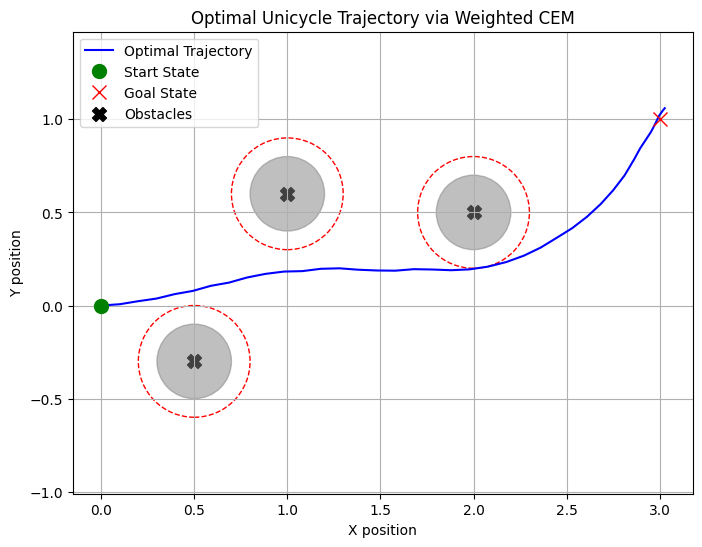

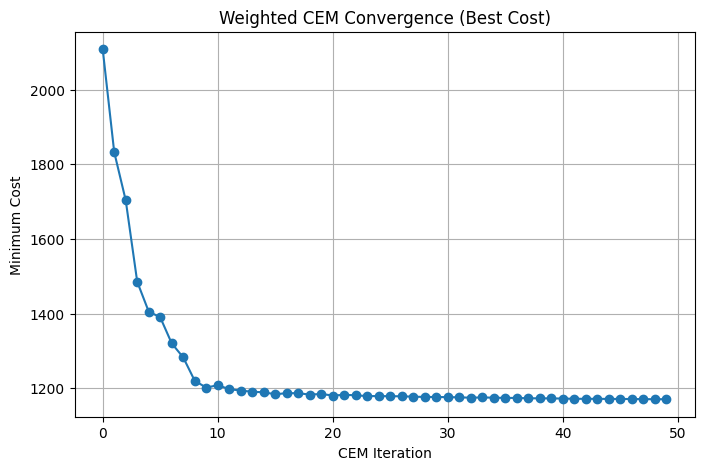

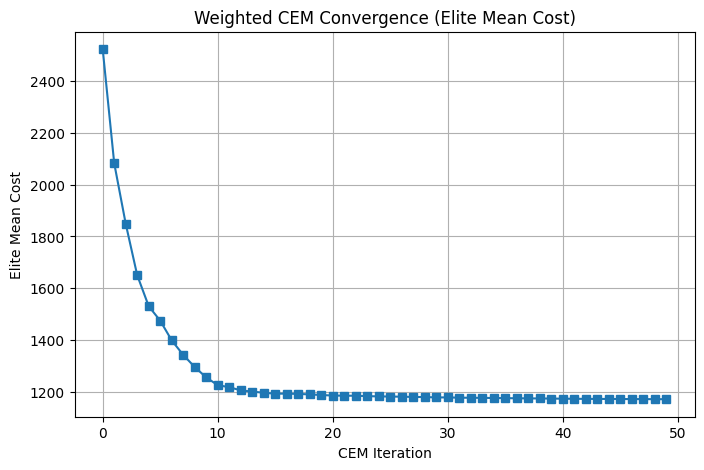

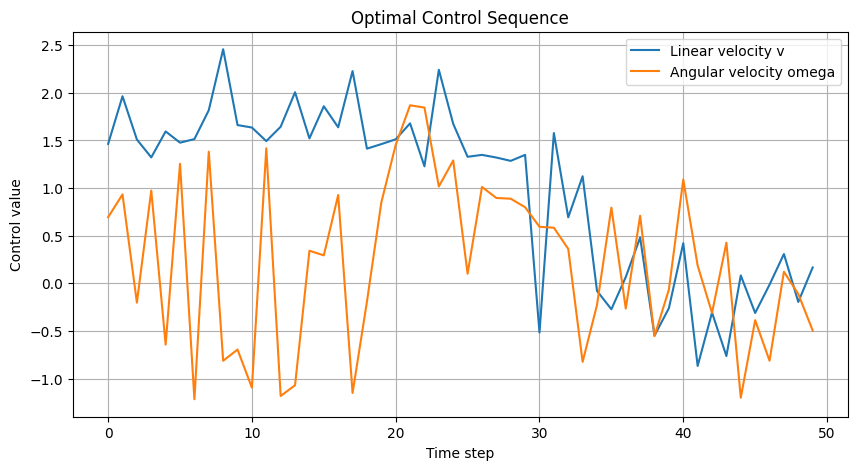

In [6]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import vmap


# ============================================================
# Problem setup
# ============================================================
H = 50          # horizon
dt = 0.1
u_dim = 2
B = 500         # number of sampled control sequences

x_init = 0.0
y_init = 0.0
theta_init = 0.0

goal_state = jnp.array([3.0, 1.0, 0.0])

obstacles = jnp.array([
    [1.0, 0.6],
    [2.0, 0.5],
    [0.5, -0.3]
])

params = {
    "w_g": 10.0,
    "w_v": 0.1,
    "w_w": 0.1,
    "w_obs": 1000.0,
    "r_obs": 0.2,
    "margin": 0.1,
    "alpha": 0.01,   # weighted CEM alpha
}


# ============================================================
# Unicycle dynamics
# ============================================================
@jax.jit
def compute_rollout_one_step(x, y, theta, u):
    v = jnp.clip(u[0], 0.0, 1.0)
    omega = jnp.clip(u[1], -1.0, 1.0)

    theta_next = theta + omega * dt
    vx_next = v * jnp.cos(theta_next)
    vy_next = v * jnp.sin(theta_next)

    x_next = x + vx_next * dt
    y_next = y + vy_next * dt

    return x_next, y_next, theta_next


@jax.jit
def compute_rollouts(x_init, y_init, theta_init, u_seq):
    u_mat = u_seq.reshape((H, 2))

    def step_fn(state, u):
        x, y, theta = state
        x_next, y_next, theta_next = compute_rollout_one_step(x, y, theta, u)
        next_state = (x_next, y_next, theta_next)
        return next_state, next_state

    init_state = (x_init, y_init, theta_init)
    _, (x_scan, y_scan, theta_scan) = jax.lax.scan(step_fn, init_state, u_mat)

    x_traj = jnp.concatenate([jnp.array([x_init]), x_scan])
    y_traj = jnp.concatenate([jnp.array([y_init]), y_scan])
    theta_traj = jnp.concatenate([jnp.array([theta_init]), theta_scan])

    return x_traj, y_traj, theta_traj


compute_rollouts_batch = vmap(compute_rollouts, in_axes=(None, None, None, 0))


# ============================================================
# Cost functions
# ============================================================
def compute_obstacle_cost(x_traj, y_traj, obstacles, params):
    w_obs = params["w_obs"]
    r_obs = params["r_obs"]
    margin = params["margin"]

    pos_traj = jnp.stack([x_traj, y_traj], axis=-1)
    pos_traj_expanded = jnp.expand_dims(pos_traj, axis=1)     # (T,1,2)
    obstacles_expanded = jnp.expand_dims(obstacles, axis=0)   # (1,N,2)

    diffs = pos_traj_expanded - obstacles_expanded
    dists = jnp.linalg.norm(diffs, axis=-1)

    in_collision = dists < (r_obs + margin)
    total_collisions = jnp.sum(in_collision)

    cost_obs = w_obs * total_collisions
    return cost_obs


def compute_goal_cost(x_traj, y_traj, theta_traj, params, goal_state):
    w_g = params["w_g"]
    cost_goal = jnp.sum((x_traj - goal_state[0]) ** 2) + jnp.sum((y_traj - goal_state[1]) ** 2)
    cost_goal = w_g * cost_goal
    return cost_goal


def compute_control_cost(u_seq):
    control_cost = 0.1 * jnp.sum(u_seq ** 2)
    return control_cost


def compute_cost(x_traj, y_traj, theta_traj, u_seq, obstacles, params, goal_state):
    cost_obs = compute_obstacle_cost(x_traj, y_traj, obstacles, params)
    cost_goal = compute_goal_cost(x_traj, y_traj, theta_traj, params, goal_state)
    control_cost = compute_control_cost(u_seq)

    return cost_obs + cost_goal + control_cost


compute_cost_batch = vmap(compute_cost, in_axes=(0, 0, 0, 0, None, None, None))


# ============================================================
# Weighted CEM update  (Problem 1)
# ============================================================
def weighted_cem_update(u_elite, cost_elite, alpha):
    """
    Weighted CEM update:
        w_i = exp(-alpha * c_i)
        W_i = w_i / sum_j w_j
        mu  = sum_i W_i u_i
        sigma = sqrt(sum_i W_i (u_i - mu)^2)
    """
    shifted_costs = cost_elite - jnp.min(cost_elite)
    weights_unnorm = jnp.exp(-alpha * shifted_costs)
    weights = weights_unnorm / (jnp.sum(weights_unnorm) + 1e-12)

    mean_u = jnp.sum(weights[:, None] * u_elite, axis=0)
    var_u = jnp.sum(weights[:, None] * (u_elite - mean_u) ** 2, axis=0)
    sigma_u = jnp.sqrt(jnp.maximum(var_u, 1e-6))

    return mean_u, sigma_u, weights


# ============================================================
# CEM parameters
# ============================================================
num_cem_iters = 50
num_elite = 30

mean_u = jnp.zeros(2 * H)
sigma_u = jnp.ones(2 * H) * 1.5

key = jax.random.PRNGKey(0)

print("Weighted CEM parameters initialized.")


# ============================================================
# Initial random rollout visualization
# ============================================================
key, subkey = jax.random.split(key)
eps = jax.random.normal(subkey, shape=(2 * H,))
u_seq = mean_u + sigma_u * eps

x_traj, y_traj, theta_traj = compute_rollouts(x_init, y_init, theta_init, u_seq)

plt.figure(figsize=(6, 5))
plt.plot(x_traj, y_traj)
plt.title("Single Random Unicycle Rollout")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.show()


# ============================================================
# Batch rollout visualization before optimization
# ============================================================
key, subkey = jax.random.split(key)
eps = jax.random.normal(subkey, shape=(B, 2 * H))
u_batch_seq = mean_u + sigma_u * eps

x_traj_batch, y_traj_batch, theta_traj_batch = compute_rollouts_batch(
    x_init, y_init, theta_init, u_batch_seq
)

plt.figure(figsize=(7, 6))
plt.plot(x_traj_batch.T, y_traj_batch.T)
plt.title("Batch of Initial Sampled Rollouts")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.show()


# ============================================================
# Weighted CEM optimization loop
# ============================================================
min_costs_per_iter = []
elite_mean_costs_per_iter = []

for i in range(num_cem_iters):
    key, subkey = jax.random.split(key)
    eps = jax.random.normal(subkey, shape=(B, 2 * H))

    # sample from current Gaussian
    u_batch_seq = mean_u + sigma_u * eps

    # rollouts
    x_traj_batch, y_traj_batch, theta_traj_batch = compute_rollouts_batch(
        x_init, y_init, theta_init, u_batch_seq
    )

    # costs
    cost_batch = compute_cost_batch(
        x_traj_batch, y_traj_batch, theta_traj_batch,
        u_batch_seq, obstacles, params, goal_state
    )

    # elite selection
    idx_sort = jnp.argsort(cost_batch)
    elite_idx = idx_sort[:num_elite]

    u_elite = u_batch_seq[elite_idx]
    cost_elite = cost_batch[elite_idx]

    # weighted update (Problem 1)
    mean_u, sigma_u, weights = weighted_cem_update(
        u_elite, cost_elite, alpha=params["alpha"]
    )

    min_costs_per_iter.append(cost_batch[idx_sort[0]])
    elite_mean_costs_per_iter.append(jnp.mean(cost_elite))

    if (i + 1) % 10 == 0 or i == 0:
        print(
            f"iter={i+1:02d}, "
            f"best_cost={float(cost_batch[idx_sort[0]]):.4f}, "
            f"elite_mean_cost={float(jnp.mean(cost_elite)):.4f}"
        )

print("\nFinal mean_u:", mean_u)
print("Final sigma_u:", sigma_u)


# ============================================================
# Optimal trajectory from final mean
# ============================================================
u_optimal = mean_u
x_traj_optimal, y_traj_optimal, theta_traj_optimal = compute_rollouts(
    x_init, y_init, theta_init, u_optimal
)

print("\nShape of optimal x_traj:", jnp.shape(x_traj_optimal))
print("Shape of optimal y_traj:", jnp.shape(y_traj_optimal))
print("Shape of optimal theta_traj:", jnp.shape(theta_traj_optimal))


# ============================================================
# Plot 1: optimal trajectory
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(x_traj_optimal, y_traj_optimal, "-b", label="Optimal Trajectory")
plt.plot(x_init, y_init, "og", markersize=10, label="Start State")
plt.plot(goal_state[0], goal_state[1], "xr", markersize=10, label="Goal State")

plt.scatter(obstacles[:, 0], obstacles[:, 1], color="k", marker="X", s=100, label="Obstacles")

ax = plt.gca()
for obs in obstacles:
    ax.add_patch(plt.Circle((float(obs[0]), float(obs[1])), params["r_obs"], color="gray", alpha=0.5))
    ax.add_patch(
        plt.Circle(
            (float(obs[0]), float(obs[1])),
            params["r_obs"] + params["margin"],
            color="red",
            fill=False,
            linestyle="--"
        )
    )

plt.xlabel("X position")
plt.ylabel("Y position")
plt.title("Optimal Unicycle Trajectory via Weighted CEM")
plt.axis("equal")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# Plot 2: best cost per iteration
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(np.array(min_costs_per_iter), marker="o")
plt.xlabel("CEM Iteration")
plt.ylabel("Minimum Cost")
plt.title("Weighted CEM Convergence (Best Cost)")
plt.grid(True)
plt.show()


# ============================================================
# Plot 3: elite mean cost per iteration
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(np.array(elite_mean_costs_per_iter), marker="s")
plt.xlabel("CEM Iteration")
plt.ylabel("Elite Mean Cost")
plt.title("Weighted CEM Convergence (Elite Mean Cost)")
plt.grid(True)
plt.show()


# ============================================================
# Plot 4: control sequence
# ============================================================
u_optimal_mat = np.array(u_optimal).reshape(H, 2)

plt.figure(figsize=(10, 5))
plt.plot(u_optimal_mat[:, 0], label="Linear velocity v")
plt.plot(u_optimal_mat[:, 1], label="Angular velocity omega")
plt.xlabel("Time step")
plt.ylabel("Control value")
plt.title("Optimal Control Sequence")
plt.legend()
plt.grid(True)
plt.show()

## Bicycle

Horizon: 100, dt: 0.1, total time: 10.0s
Batch size: 500, elite: 30, CEM iters: 60
Goal state: [10.  3.  0.  0.]


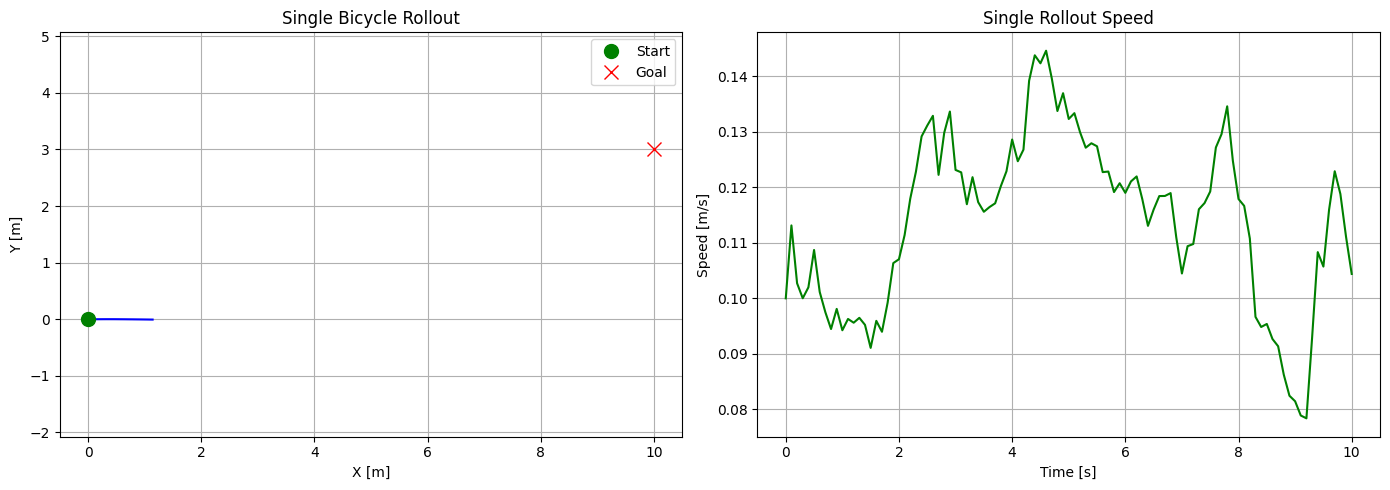

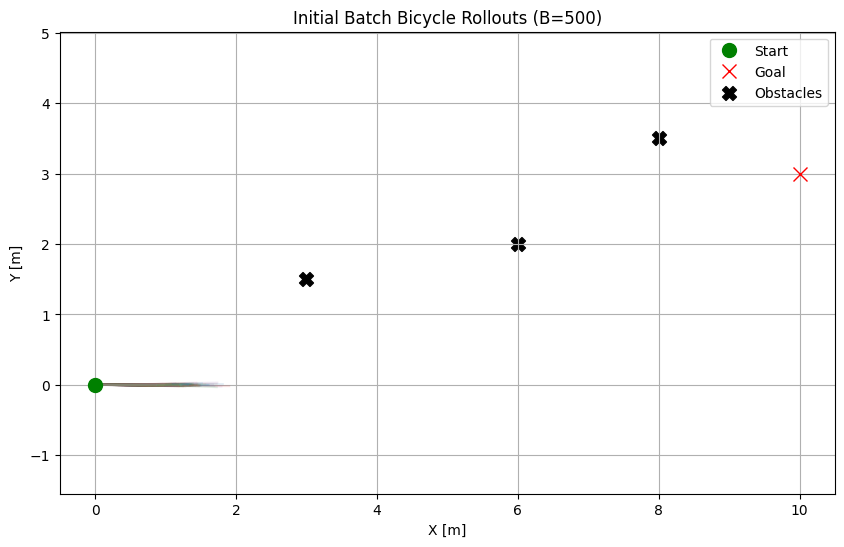

Iter 01/60 | Best cost: 15805.114 | Elite mean: 16566.293
Iter 10/60 | Best cost: 4282.130 | Elite mean: 4769.627
Iter 20/60 | Best cost: 525.062 | Elite mean: 616.937
Iter 30/60 | Best cost: 422.628 | Elite mean: 425.382
Iter 40/60 | Best cost: 388.323 | Elite mean: 389.876
Iter 50/60 | Best cost: 366.459 | Elite mean: 368.002
Iter 60/60 | Best cost: 353.857 | Elite mean: 354.769

Final best cost: 353.857
Final position: (9.954, 2.967)
Goal position : (10.000, 3.000)
Final position error: 0.056
Final heading error : 0.357 rad
Final speed error   : 1.138 m/s


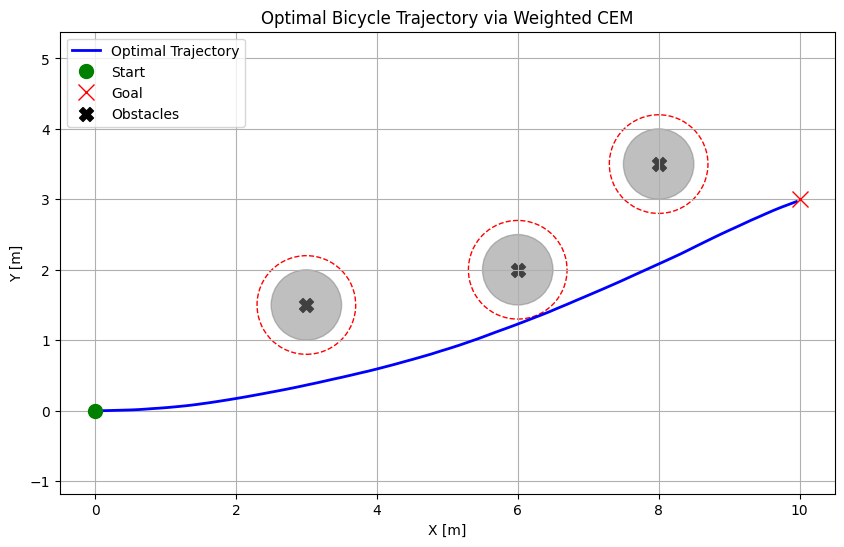

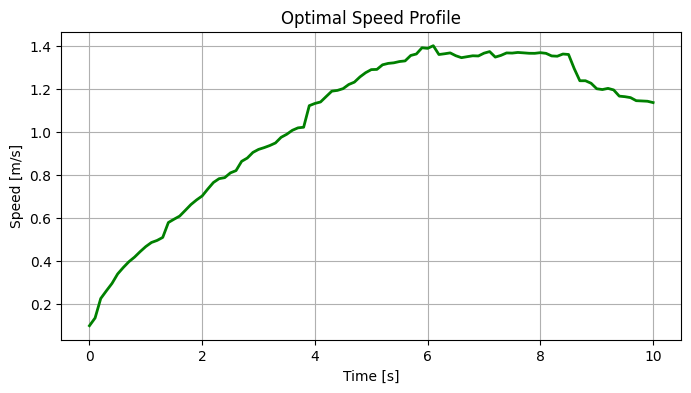

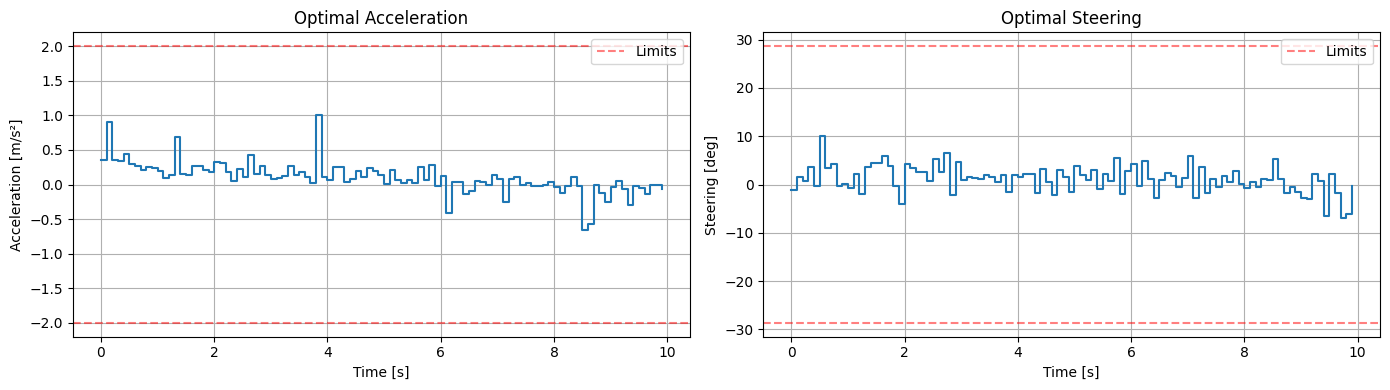

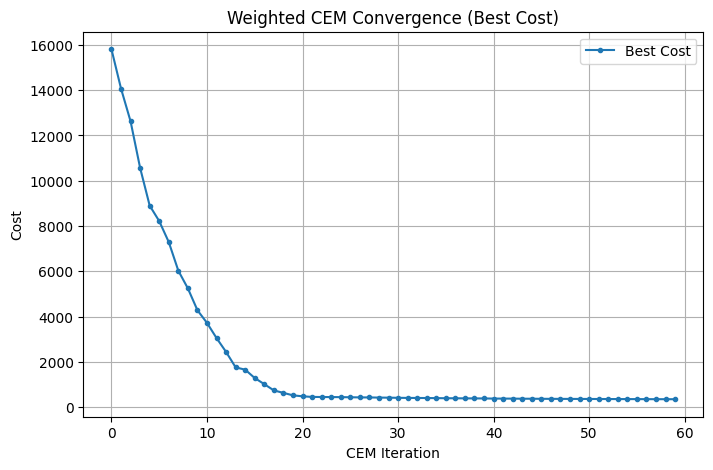

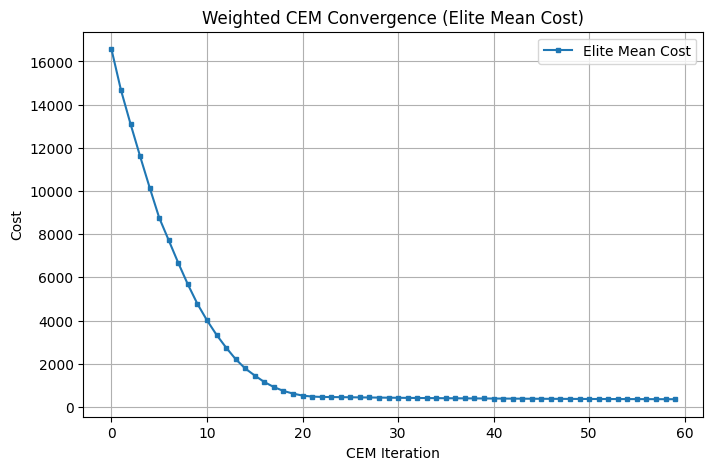

In [8]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import vmap


# ============================================================
# Planning parameters
# ============================================================
H = 100
dt = 0.1
B = 500

# Bicycle parameters
L = 0.5

# Control limits
a_min, a_max = -2.0, 2.0
delta_min, delta_max = -0.5, 0.5
v_min, v_max = 0.0, 2.0

# Initial state
x_init = 0.0
y_init = 0.0
theta_init = 0.0
v_init = 0.1

# Goal state: [x_g, y_g, theta_g, v_g]
goal_state = jnp.array([10.0, 3.0, 0.0, 0.0])

# Obstacles
obstacles = jnp.array([
    [3.0, 1.5],
    [6.0, 2.0],
    [8.0, 3.5]
])

# Cost / CEM parameters
params = {
    "w_g": 200.0,        # terminal position weight
    "w_theta": 20.0,     # terminal heading weight
    "w_v": 80.0,         # terminal speed weight
    "w_prog": 0.05,      # small running progress cost
    "w_a": 0.2,          # acceleration regularization
    "w_delta": 1.0,      # steering regularization
    "w_smooth_a": 0.5,   # smooth acceleration
    "w_smooth_delta": 1.0,  # smooth steering
    "w_obs": 1000.0,
    "r_obs": 0.5,
    "margin": 0.2,
    "alpha": 0.001,      # weighted CEM sharpness
}

num_cem_iters = 60
num_elite = 30

print(f"Horizon: {H}, dt: {dt}, total time: {H*dt:.1f}s")
print(f"Batch size: {B}, elite: {num_elite}, CEM iters: {num_cem_iters}")
print("Goal state:", goal_state)


# ============================================================
# Helpers
# ============================================================
@jax.jit
def angle_wrap(a):
    return jnp.arctan2(jnp.sin(a), jnp.cos(a))


# ============================================================
# Bicycle dynamics
# State: [x, y, theta, v]
# Control: [a, delta]
# ============================================================
@jax.jit
def compute_rollout_one_step(x, y, theta, v, u):
    a = jnp.clip(u[0], a_min, a_max)
    delta = jnp.clip(u[1], delta_min, delta_max)

    v_next = jnp.clip(v + a * dt, v_min, v_max)
    v_avg = 0.5 * (v + v_next)

    theta_next = theta + (v_avg / L) * jnp.tan(delta) * dt
    x_next = x + v_avg * jnp.cos(theta_next) * dt
    y_next = y + v_avg * jnp.sin(theta_next) * dt

    return x_next, y_next, theta_next, v_next


@jax.jit
def compute_rollouts(x_init, y_init, theta_init, v_init, u_seq):
    u_mat = u_seq.reshape((H, 2))

    def step_fn(state, u):
        x, y, theta, v = state
        x_next, y_next, theta_next, v_next = compute_rollout_one_step(x, y, theta, v, u)
        next_state = (x_next, y_next, theta_next, v_next)
        return next_state, next_state

    init_state = (x_init, y_init, theta_init, v_init)
    _, (x_scan, y_scan, theta_scan, v_scan) = jax.lax.scan(step_fn, init_state, u_mat)

    x_traj = jnp.concatenate([jnp.array([x_init]), x_scan])
    y_traj = jnp.concatenate([jnp.array([y_init]), y_scan])
    theta_traj = jnp.concatenate([jnp.array([theta_init]), theta_scan])
    v_traj = jnp.concatenate([jnp.array([v_init]), v_scan])

    return x_traj, y_traj, theta_traj, v_traj


compute_rollouts_batch = vmap(compute_rollouts, in_axes=(None, None, None, None, 0))


# ============================================================
# Cost functions
# ============================================================
def compute_obstacle_cost(x_traj, y_traj, obstacles, params):
    w_obs = params["w_obs"]
    r_obs = params["r_obs"]
    margin = params["margin"]

    pos_traj = jnp.stack([x_traj, y_traj], axis=-1)            # (H+1, 2)
    pos_traj_expanded = pos_traj[:, None, :]                   # (H+1, 1, 2)
    obstacles_expanded = obstacles[None, :, :]                 # (1, Nobs, 2)

    diffs = pos_traj_expanded - obstacles_expanded
    dists = jnp.linalg.norm(diffs, axis=-1)

    in_collision = dists < (r_obs + margin)
    total_collisions = jnp.sum(in_collision)

    return w_obs * total_collisions


def compute_goal_cost(x_traj, y_traj, theta_traj, v_traj, params, goal_state):
    # Strong terminal cost to stop overshooting
    cost_terminal_pos = params["w_g"] * (
        (x_traj[-1] - goal_state[0]) ** 2 +
        (y_traj[-1] - goal_state[1]) ** 2
    )

    cost_terminal_theta = params["w_theta"] * angle_wrap(theta_traj[-1] - goal_state[2]) ** 2
    cost_terminal_v = params["w_v"] * (v_traj[-1] - goal_state[3]) ** 2

    # Small running progress term
    cost_running = params["w_prog"] * (
        jnp.sum((x_traj - goal_state[0]) ** 2) +
        jnp.sum((y_traj - goal_state[1]) ** 2)
    )

    return cost_terminal_pos + cost_terminal_theta + cost_terminal_v + cost_running


def compute_control_cost(u_seq, params):
    u_mat = u_seq.reshape((H, 2))
    a_seq = u_mat[:, 0]
    delta_seq = u_mat[:, 1]

    cost_a = params["w_a"] * jnp.sum(a_seq ** 2)
    cost_delta = params["w_delta"] * jnp.sum(delta_seq ** 2)

    # smoothness
    da = a_seq[1:] - a_seq[:-1]
    ddelta = delta_seq[1:] - delta_seq[:-1]

    cost_smooth_a = params["w_smooth_a"] * jnp.sum(da ** 2)
    cost_smooth_delta = params["w_smooth_delta"] * jnp.sum(ddelta ** 2)

    return cost_a + cost_delta + cost_smooth_a + cost_smooth_delta


def compute_cost(x_traj, y_traj, theta_traj, v_traj, u_seq, obstacles, params, goal_state):
    cost_obs = compute_obstacle_cost(x_traj, y_traj, obstacles, params)
    cost_goal = compute_goal_cost(x_traj, y_traj, theta_traj, v_traj, params, goal_state)
    cost_control = compute_control_cost(u_seq, params)
    return cost_obs + cost_goal + cost_control


compute_cost_batch = vmap(compute_cost, in_axes=(0, 0, 0, 0, 0, None, None, None))


# ============================================================
# Weighted CEM update (Problem 1)
# ============================================================
def weighted_cem_update(u_elite, cost_elite, alpha):
    shifted_costs = cost_elite - jnp.min(cost_elite)
    weights_unnorm = jnp.exp(-alpha * shifted_costs)
    weights = weights_unnorm / (jnp.sum(weights_unnorm) + 1e-12)

    mean_u = jnp.sum(weights[:, None] * u_elite, axis=0)
    var_u = jnp.sum(weights[:, None] * (u_elite - mean_u) ** 2, axis=0)
    sigma_u = jnp.sqrt(jnp.maximum(var_u, 1e-6))

    return mean_u, sigma_u, weights


# ============================================================
# Initial single rollout demo
# ============================================================
key = jax.random.PRNGKey(2)
key, subkey = jax.random.split(key)

mean_u_demo = jnp.zeros(2 * H)
sigma_u_demo = jnp.ones(2 * H) * 0.05
eps = jax.random.normal(subkey, shape=(2 * H,))
u_seq_demo = mean_u_demo + sigma_u_demo * eps

x_demo, y_demo, theta_demo, v_demo = compute_rollouts(
    x_init, y_init, theta_init, v_init, u_seq_demo
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(x_demo, y_demo, "-b")
axes[0].plot(x_init, y_init, "og", markersize=10, label="Start")
axes[0].plot(goal_state[0], goal_state[1], "xr", markersize=10, label="Goal")
axes[0].set_title("Single Bicycle Rollout")
axes[0].set_xlabel("X [m]")
axes[0].set_ylabel("Y [m]")
axes[0].axis("equal")
axes[0].grid(True)
axes[0].legend()

t_axis = jnp.arange(H + 1) * dt
axes[1].plot(t_axis, v_demo, "-g")
axes[1].set_title("Single Rollout Speed")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Speed [m/s]")
axes[1].grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# Initial batch rollout demo
# ============================================================
key, subkey = jax.random.split(key)
eps = jax.random.normal(subkey, shape=(B, 2 * H))

u_batch_demo = mean_u_demo + sigma_u_demo * eps
x_batch_demo, y_batch_demo, theta_batch_demo, v_batch_demo = compute_rollouts_batch(
    x_init, y_init, theta_init, v_init, u_batch_demo
)

plt.figure(figsize=(10, 6))
plt.plot(x_batch_demo.T, y_batch_demo.T, alpha=0.12)
plt.plot(x_init, y_init, "og", markersize=10, label="Start")
plt.plot(goal_state[0], goal_state[1], "xr", markersize=10, label="Goal")
plt.scatter(obstacles[:, 0], obstacles[:, 1], color="k", marker="X", s=100, label="Obstacles")
plt.title(f"Initial Batch Bicycle Rollouts (B={B})")
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# Weighted CEM optimization loop
# ============================================================
mean_u = jnp.zeros(2 * H)
sigma_u = jnp.ones(2 * H) * 0.05   # smaller variance helps reduce overshoot
key = jax.random.PRNGKey(0)

min_costs_per_iter = []
elite_mean_costs_per_iter = []

for i in range(num_cem_iters):
    key, subkey = jax.random.split(key)
    eps = jax.random.normal(subkey, shape=(B, 2 * H))

    u_batch_seq = mean_u + sigma_u * eps

    x_traj_batch, y_traj_batch, theta_traj_batch, v_traj_batch = compute_rollouts_batch(
        x_init, y_init, theta_init, v_init, u_batch_seq
    )

    cost_batch = compute_cost_batch(
        x_traj_batch, y_traj_batch, theta_traj_batch, v_traj_batch,
        u_batch_seq, obstacles, params, goal_state
    )

    idx_sort = jnp.argsort(cost_batch)
    elite_idx = idx_sort[:num_elite]

    u_elite = u_batch_seq[elite_idx]
    cost_elite = cost_batch[elite_idx]

    mean_u, sigma_u, weights = weighted_cem_update(
        u_elite, cost_elite, alpha=params["alpha"]
    )

    min_costs_per_iter.append(cost_batch[idx_sort[0]])
    elite_mean_costs_per_iter.append(jnp.mean(cost_elite))

    if (i + 1) % 10 == 0 or i == 0:
        print(
            f"Iter {i+1:02d}/{num_cem_iters} | "
            f"Best cost: {float(cost_batch[idx_sort[0]]):.3f} | "
            f"Elite mean: {float(jnp.mean(cost_elite)):.3f}"
        )

print(f"\nFinal best cost: {float(min_costs_per_iter[-1]):.3f}")


# ============================================================
# Optimal trajectory from final mean
# ============================================================
u_optimal = mean_u
x_opt, y_opt, theta_opt, v_opt = compute_rollouts(
    x_init, y_init, theta_init, v_init, u_optimal
)

final_pos_err = float(jnp.sqrt((x_opt[-1] - goal_state[0]) ** 2 + (y_opt[-1] - goal_state[1]) ** 2))
final_heading_err = float(angle_wrap(theta_opt[-1] - goal_state[2]))
final_speed_err = float(v_opt[-1] - goal_state[3])

print(f"Final position: ({float(x_opt[-1]):.3f}, {float(y_opt[-1]):.3f})")
print(f"Goal position : ({float(goal_state[0]):.3f}, {float(goal_state[1]):.3f})")
print(f"Final position error: {final_pos_err:.3f}")
print(f"Final heading error : {final_heading_err:.3f} rad")
print(f"Final speed error   : {final_speed_err:.3f} m/s")


# ============================================================
# Plot optimal trajectory
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(x_opt, y_opt, "-b", linewidth=2, label="Optimal Trajectory")
plt.plot(x_init, y_init, "og", markersize=10, label="Start")
plt.plot(goal_state[0], goal_state[1], "xr", markersize=12, label="Goal")

plt.scatter(obstacles[:, 0], obstacles[:, 1], color="k", marker="X", s=100, label="Obstacles")
ax = plt.gca()
for obs in obstacles:
    ax.add_patch(plt.Circle((float(obs[0]), float(obs[1])), params["r_obs"], color="gray", alpha=0.5))
    ax.add_patch(
        plt.Circle(
            (float(obs[0]), float(obs[1])),
            params["r_obs"] + params["margin"],
            color="red",
            fill=False,
            linestyle="--"
        )
    )

plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Optimal Bicycle Trajectory via Weighted CEM")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# Plot speed profile
# ============================================================
t_axis = jnp.arange(H + 1) * dt

plt.figure(figsize=(8, 4))
plt.plot(t_axis, v_opt, "-g", linewidth=2)
plt.xlabel("Time [s]")
plt.ylabel("Speed [m/s]")
plt.title("Optimal Speed Profile")
plt.grid(True)
plt.show()


# ============================================================
# Plot control profiles
# ============================================================
u_opt_mat = np.array(u_optimal).reshape(H, 2)
t_ctrl = np.arange(H) * dt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].step(t_ctrl, u_opt_mat[:, 0], where="post", linewidth=1.5)
axes[0].axhline(a_min, color="r", linestyle="--", alpha=0.5, label="Limits")
axes[0].axhline(a_max, color="r", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Acceleration [m/s²]")
axes[0].set_title("Optimal Acceleration")
axes[0].grid(True)
axes[0].legend()

axes[1].step(t_ctrl, np.degrees(u_opt_mat[:, 1]), where="post", linewidth=1.5)
axes[1].axhline(np.degrees(delta_min), color="r", linestyle="--", alpha=0.5, label="Limits")
axes[1].axhline(np.degrees(delta_max), color="r", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Steering [deg]")
axes[1].set_title("Optimal Steering")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


# ============================================================
# Plot convergence
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(np.array(min_costs_per_iter), "-o", markersize=3, label="Best Cost")
plt.xlabel("CEM Iteration")
plt.ylabel("Cost")
plt.title("Weighted CEM Convergence (Best Cost)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(np.array(elite_mean_costs_per_iter), "-s", markersize=3, label="Elite Mean Cost")
plt.xlabel("CEM Iteration")
plt.ylabel("Cost")
plt.title("Weighted CEM Convergence (Elite Mean Cost)")
plt.grid(True)
plt.legend()
plt.show()

# Problem 2

## Unicycle

Required safe distance: 0.8
Iter 001/450 | best_cost=32006406.000 | min_dist=0.857
Iter 020/450 | best_cost=8795823.000 | min_dist=0.815
Iter 040/450 | best_cost=3688650.000 | min_dist=0.802
Iter 060/450 | best_cost=1694418.875 | min_dist=0.802
Iter 080/450 | best_cost=615458.938 | min_dist=0.800
Iter 100/450 | best_cost=401161.406 | min_dist=0.805
Iter 120/450 | best_cost=333858.531 | min_dist=0.806
Iter 140/450 | best_cost=189649.422 | min_dist=0.804
Iter 160/450 | best_cost=98404.016 | min_dist=0.802
Iter 180/450 | best_cost=63177.957 | min_dist=0.803
Iter 200/450 | best_cost=46809.414 | min_dist=0.805
Iter 220/450 | best_cost=34766.730 | min_dist=0.803
Iter 240/450 | best_cost=24447.752 | min_dist=0.800
Iter 260/450 | best_cost=17485.205 | min_dist=0.808
Iter 280/450 | best_cost=12023.707 | min_dist=0.805
Iter 300/450 | best_cost=8404.770 | min_dist=0.812
Iter 320/450 | best_cost=5175.587 | min_dist=0.801
Iter 340/450 | best_cost=3209.907 | min_dist=0.804
Iter 360/450 | best_cost=1

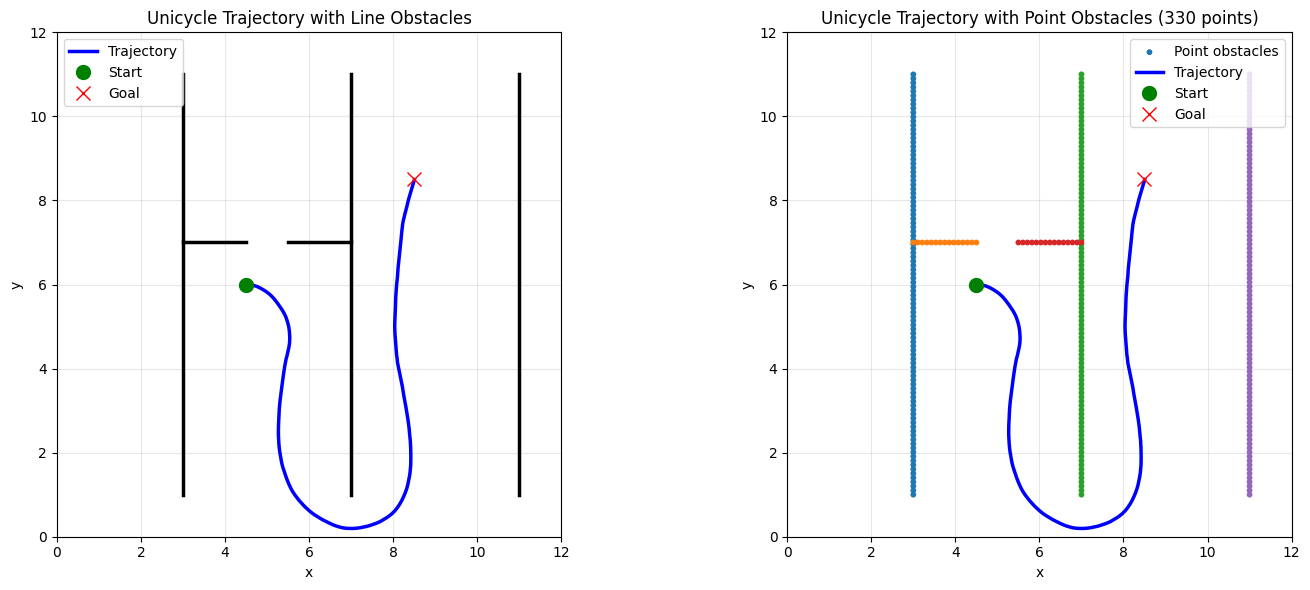

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import vmap


# ============================================================
# Obstacle generation
# ============================================================
def line_to_points(start, end, spacing=0.1):
    start = np.array(start, dtype=float)
    end = np.array(end, dtype=float)
    length = np.linalg.norm(end - start)
    n_points = max(int(np.ceil(length / spacing)), 2)
    t = np.linspace(0, 1, n_points)
    points = np.column_stack([
        start[0] + t * (end[0] - start[0]),
        start[1] + t * (end[1] - start[1])
    ])
    return points


def create_workspace_obstacles(spacing=0.1):
    line_segments = [
        ((3.0, 11.0), (3.0, 1.0)),
        ((3.0, 7.0), (4.5, 7.0)),
        ((7.0, 11.0), (7.0, 1.0)),
        ((5.5, 7.0), (7.0, 7.0)),
        ((11.0, 11.0), (11.0, 1.0)),
    ]

    all_points = []
    segment_labels = []

    for i, (start, end) in enumerate(line_segments):
        pts = line_to_points(start, end, spacing=spacing)
        all_points.append(pts)
        segment_labels.extend([i] * len(pts))

    point_cloud = np.vstack(all_points)
    segment_labels = np.array(segment_labels)

    return point_cloud, segment_labels, line_segments


# ============================================================
# Global settings
# ============================================================
X_MIN, X_MAX = 0.0, 12.0
Y_MIN, Y_MAX = 0.0, 12.0

R_OBS = 0.3
R_ROBOT = 0.5
SAFE_DIST = R_OBS + R_ROBOT   # 0.8

dt = 0.1
H = 180
NUM_ELITE = 140
NUM_ITERS = 450
B = 2200


# ============================================================
# Start / goal
# ============================================================
x_init = 4.5
y_init = 6.0
theta_init = 0.0
goal_state = jnp.array([8.5, 8.5, 0.0])


# ============================================================
# Parameters
# ============================================================
params = {
    "w_goal_terminal": 5000.0,
    "w_goal_running": 0.01,
    "w_theta_terminal": 80.0,
    "w_v": 0.03,
    "w_w": 0.04,
    "w_smooth_v": 0.25,
    "w_smooth_w": 0.40,
    "w_obs_soft": 200000.0,
    "w_obs_hard": 1200000.0,
    "w_bounds": 50000.0,
    "alpha": 0.0015,
}


# ============================================================
# Helpers
# ============================================================
@jax.jit
def angle_wrap(a):
    return jnp.arctan2(jnp.sin(a), jnp.cos(a))


@jax.jit
def step_unicycle(x, y, theta, u):
    v = jnp.clip(u[0], 0.0, 1.0)
    omega = jnp.clip(u[1], -1.4, 1.4)

    theta_next = theta + omega * dt
    x_next = x + v * jnp.cos(theta_next) * dt
    y_next = y + v * jnp.sin(theta_next) * dt

    return x_next, y_next, theta_next


@jax.jit
def rollout_unicycle(x0, y0, th0, u_seq):
    u_mat = u_seq.reshape((H, 2))

    def step_fn(state, u):
        x, y, th = state
        x_next, y_next, th_next = step_unicycle(x, y, th, u)
        next_state = (x_next, y_next, th_next)
        return next_state, next_state

    init_state = (x0, y0, th0)
    _, (x_scan, y_scan, th_scan) = jax.lax.scan(step_fn, init_state, u_mat)

    x_traj = jnp.concatenate([jnp.array([x0]), x_scan])
    y_traj = jnp.concatenate([jnp.array([y0]), y_scan])
    th_traj = jnp.concatenate([jnp.array([th0]), th_scan])

    return x_traj, y_traj, th_traj


rollout_unicycle_batch = vmap(rollout_unicycle, in_axes=(None, None, None, 0))


# ============================================================
# Line-segment distance
# ============================================================
def segments_to_arrays(line_segments):
    p0 = np.array([s for s, e in line_segments], dtype=np.float32)
    p1 = np.array([e for s, e in line_segments], dtype=np.float32)
    return jnp.asarray(p0), jnp.asarray(p1)


def point_to_segment_distance(points, seg_starts, seg_ends):
    """
    points:      (T, 2)
    seg_starts:  (M, 2)
    seg_ends:    (M, 2)
    returns:
        dists: (T, M)
    """
    p = points[:, None, :]                # (T,1,2)
    a = seg_starts[None, :, :]            # (1,M,2)
    b = seg_ends[None, :, :]              # (1,M,2)

    ab = b - a                            # (1,M,2)
    ap = p - a                            # (T,M,2)

    ab2 = jnp.sum(ab * ab, axis=-1)       # (1,M)
    t = jnp.sum(ap * ab, axis=-1) / (ab2 + 1e-12)   # (T,M)
    t = jnp.clip(t, 0.0, 1.0)

    proj = a + t[..., None] * ab          # (T,M,2)
    d = jnp.linalg.norm(p - proj, axis=-1)
    return d


# ============================================================
# Cost functions
# ============================================================
def compute_obstacle_cost(x_traj, y_traj, seg_starts, seg_ends, params):
    pos = jnp.stack([x_traj, y_traj], axis=-1)        # (T,2)
    dists = point_to_segment_distance(pos, seg_starts, seg_ends)  # (T,M)

    dmin_each = jnp.min(dists, axis=1)
    min_dist = jnp.min(dmin_each)

    penetration = jnp.maximum(SAFE_DIST - dmin_each, 0.0)
    cost_soft = params["w_obs_soft"] * jnp.sum(penetration ** 2)

    collision_steps = jnp.sum((dmin_each < SAFE_DIST).astype(jnp.float32))
    cost_hard = params["w_obs_hard"] * collision_steps

    return cost_soft + cost_hard, min_dist


def compute_bounds_cost(x_traj, y_traj, params):
    px1 = jnp.maximum(X_MIN - x_traj, 0.0)
    px2 = jnp.maximum(x_traj - X_MAX, 0.0)
    py1 = jnp.maximum(Y_MIN - y_traj, 0.0)
    py2 = jnp.maximum(y_traj - Y_MAX, 0.0)

    return params["w_bounds"] * jnp.sum(px1**2 + px2**2 + py1**2 + py2**2)


def compute_goal_cost(x_traj, y_traj, th_traj, goal_state, params):
    terminal_pos = params["w_goal_terminal"] * (
        (x_traj[-1] - goal_state[0]) ** 2 +
        (y_traj[-1] - goal_state[1]) ** 2
    )

    terminal_theta = params["w_theta_terminal"] * (
        angle_wrap(th_traj[-1] - goal_state[2]) ** 2
    )

    running_pos = params["w_goal_running"] * (
        jnp.sum((x_traj - goal_state[0]) ** 2) +
        jnp.sum((y_traj - goal_state[1]) ** 2)
    )

    return terminal_pos + terminal_theta + running_pos


def compute_control_cost(u_seq, params):
    u_mat = u_seq.reshape((H, 2))
    v_seq = u_mat[:, 0]
    w_seq = u_mat[:, 1]

    mag = params["w_v"] * jnp.sum(v_seq ** 2) + params["w_w"] * jnp.sum(w_seq ** 2)

    dv = v_seq[1:] - v_seq[:-1]
    dw = w_seq[1:] - w_seq[:-1]

    smooth = params["w_smooth_v"] * jnp.sum(dv ** 2) + params["w_smooth_w"] * jnp.sum(dw ** 2)

    return mag + smooth


def compute_cost(x_traj, y_traj, th_traj, u_seq, seg_starts, seg_ends, goal_state, params):
    cost_obs, min_dist = compute_obstacle_cost(x_traj, y_traj, seg_starts, seg_ends, params)
    cost_goal = compute_goal_cost(x_traj, y_traj, th_traj, goal_state, params)
    cost_ctrl = compute_control_cost(u_seq, params)
    cost_bounds = compute_bounds_cost(x_traj, y_traj, params)

    total = cost_obs + cost_goal + cost_ctrl + cost_bounds
    return total, min_dist


def compute_cost_batch(xb, yb, tb, ub, seg_starts, seg_ends, goal_state, params):
    def one_cost(x, y, t, u):
        return compute_cost(x, y, t, u, seg_starts, seg_ends, goal_state, params)
    return vmap(one_cost)(xb, yb, tb, ub)


# ============================================================
# Weighted CEM update
# ============================================================
def weighted_cem_update(u_elite, cost_elite, alpha):
    shifted = cost_elite - jnp.min(cost_elite)
    w = jnp.exp(-alpha * shifted)
    weights = w / (jnp.sum(w) + 1e-12)

    mean_u = jnp.sum(weights[:, None] * u_elite, axis=0)
    var_u = jnp.sum(weights[:, None] * (u_elite - mean_u) ** 2, axis=0)
    sigma_u = jnp.sqrt(jnp.maximum(var_u, 1e-4))

    return mean_u, sigma_u


# ============================================================
# One-phase smarter initialization
# ============================================================
def build_initial_mean():
    u = np.zeros((H, 2), dtype=np.float32)

    u[0:28, 0] = 0.9
    u[0:28, 1] = -0.42

    u[28:95, 0] = 1.0
    u[28:95, 1] = 0.0

    u[95:132, 0] = 0.9
    u[95:132, 1] = 0.58

    u[132:165, 0] = 0.75
    u[132:165, 1] = 0.08

    u[165:180, 0] = 0.45
    u[165:180, 1] = -0.08

    return jnp.asarray(u.reshape(-1))


# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    SPACING = 0.10
    point_cloud_np, labels_np, line_segments = create_workspace_obstacles(spacing=SPACING)

    seg_starts, seg_ends = segments_to_arrays(line_segments)

    print("Required safe distance:", SAFE_DIST)

    mean_u = build_initial_mean()
    sigma_u = jnp.tile(jnp.array([0.14, 0.20]), (H,))

    key = jax.random.PRNGKey(0)

    best_cost = jnp.inf
    best_u = mean_u
    best_min_dist = -1.0

    for i in range(NUM_ITERS):
        key, subkey = jax.random.split(key)
        eps = jax.random.normal(subkey, shape=(B, 2 * H))

        u_batch_seq = mean_u + sigma_u * eps

        u_batch_mat = u_batch_seq.reshape(B, H, 2)
        v_batch = jnp.clip(u_batch_mat[:, :, 0], 0.0, 1.0)
        w_batch = jnp.clip(u_batch_mat[:, :, 1], -1.4, 1.4)
        u_batch_seq = jnp.stack([v_batch, w_batch], axis=-1).reshape(B, 2 * H)

        x_batch, y_batch, th_batch = rollout_unicycle_batch(
            x_init, y_init, theta_init, u_batch_seq
        )

        cost_batch, min_dist_batch = compute_cost_batch(
            x_batch, y_batch, th_batch, u_batch_seq,
            seg_starts, seg_ends, goal_state, params
        )

        idx_sort = jnp.argsort(cost_batch)
        elite_idx = idx_sort[:NUM_ELITE]

        u_elite = u_batch_seq[elite_idx]
        cost_elite = cost_batch[elite_idx]

        mean_u, sigma_u = weighted_cem_update(
            u_elite, cost_elite, params["alpha"]
        )

        sigma_u = jnp.maximum(sigma_u, 0.015)

        iter_best = idx_sort[0]
        if cost_batch[iter_best] < best_cost:
            best_cost = cost_batch[iter_best]
            best_u = u_batch_seq[iter_best]
            best_min_dist = float(min_dist_batch[iter_best])

        if (i + 1) % 20 == 0 or i == 0:
            print(
                f"Iter {i+1:03d}/{NUM_ITERS} | "
                f"best_cost={float(cost_batch[iter_best]):.3f} | "
                f"min_dist={float(min_dist_batch[iter_best]):.3f}"
            )

    x_opt, y_opt, th_opt = rollout_unicycle(x_init, y_init, theta_init, best_u)
    final_cost, final_min_dist = compute_cost(
        x_opt, y_opt, th_opt, best_u, seg_starts, seg_ends, goal_state, params
    )

    collision_free = float(final_min_dist) >= SAFE_DIST

    print("\nFinal results")
    print("Final cost:", float(final_cost))
    print("Final min distance:", float(final_min_dist))
    print("Collision free:", collision_free)
    print("Final state:", (float(x_opt[-1]), float(y_opt[-1]), float(th_opt[-1])))

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    ax = axes[0]
    for start, end in line_segments:
        ax.plot([start[0], end[0]], [start[1], end[1]], "k-", linewidth=2.5)
    ax.plot(x_opt, y_opt, "-b", linewidth=2.5, label="Trajectory")
    ax.plot(x_init, y_init, "og", markersize=10, label="Start")
    ax.plot(goal_state[0], goal_state[1], "xr", markersize=10, label="Goal")
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 12)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_title("Unicycle Trajectory with Line Obstacles")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

    ax = axes[1]
    colors = plt.cm.tab10(labels_np % 10)
    ax.scatter(point_cloud_np[:, 0], point_cloud_np[:, 1], c=colors, s=10, zorder=2, label="Point obstacles")
    ax.plot(x_opt, y_opt, "-b", linewidth=2.5, label="Trajectory")
    ax.plot(x_init, y_init, "og", markersize=10, label="Start")
    ax.plot(goal_state[0], goal_state[1], "xr", markersize=10, label="Goal")
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 12)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Unicycle Trajectory with Point Obstacles ({len(point_cloud_np)} points)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

    plt.tight_layout()
    plt.show()

# Bicycle

Required safe distance: 0.8
Iter 001/450 | best_cost=18430084.000 | min_dist=0.756
Iter 020/450 | best_cost=2183872.500 | min_dist=0.809
Iter 040/450 | best_cost=124841.289 | min_dist=0.801
Iter 060/450 | best_cost=36592.453 | min_dist=0.801
Iter 080/450 | best_cost=2509.869 | min_dist=0.815
Iter 100/450 | best_cost=368.310 | min_dist=0.868
Iter 120/450 | best_cost=340.931 | min_dist=0.872
Iter 140/450 | best_cost=315.283 | min_dist=0.918
Iter 160/450 | best_cost=293.939 | min_dist=0.894
Iter 180/450 | best_cost=280.343 | min_dist=0.889
Iter 200/450 | best_cost=262.339 | min_dist=0.823
Iter 220/450 | best_cost=249.133 | min_dist=0.850
Iter 240/450 | best_cost=235.947 | min_dist=0.833
Iter 260/450 | best_cost=225.083 | min_dist=0.843
Iter 280/450 | best_cost=210.112 | min_dist=0.827
Iter 300/450 | best_cost=205.446 | min_dist=0.825
Iter 320/450 | best_cost=197.495 | min_dist=0.819
Iter 340/450 | best_cost=189.524 | min_dist=0.812
Iter 360/450 | best_cost=181.635 | min_dist=0.800
Iter 38

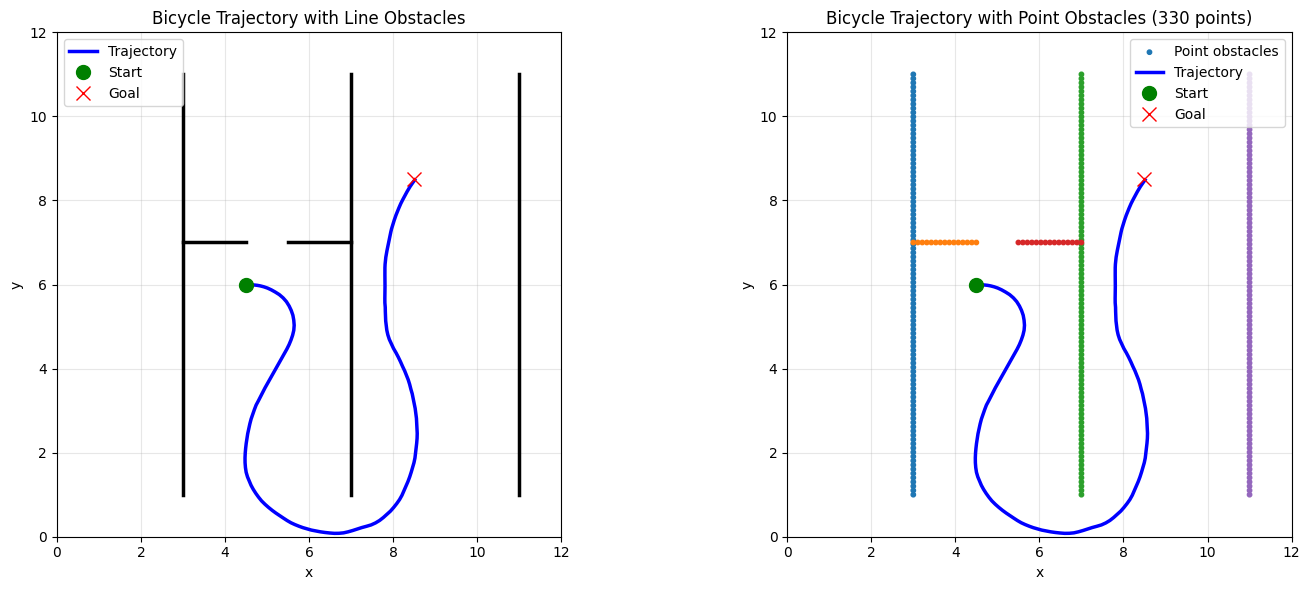

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import vmap


# ============================================================
# Obstacle generation
# ============================================================
def line_to_points(start, end, spacing=0.1):
    start = np.array(start, dtype=float)
    end = np.array(end, dtype=float)
    length = np.linalg.norm(end - start)
    n_points = max(int(np.ceil(length / spacing)), 2)
    t = np.linspace(0, 1, n_points)
    points = np.column_stack([
        start[0] + t * (end[0] - start[0]),
        start[1] + t * (end[1] - start[1])
    ])
    return points


def create_workspace_obstacles(spacing=0.1):
    line_segments = [
        ((3.0, 11.0), (3.0, 1.0)),
        ((3.0, 7.0), (4.5, 7.0)),
        ((7.0, 11.0), (7.0, 1.0)),
        ((5.5, 7.0), (7.0, 7.0)),
        ((11.0, 11.0), (11.0, 1.0)),
    ]

    all_points = []
    segment_labels = []

    for i, (start, end) in enumerate(line_segments):
        pts = line_to_points(start, end, spacing=spacing)
        all_points.append(pts)
        segment_labels.extend([i] * len(pts))

    point_cloud = np.vstack(all_points)
    segment_labels = np.array(segment_labels)

    return point_cloud, segment_labels, line_segments


# ============================================================
# Global settings
# ============================================================
X_MIN, X_MAX = 0.0, 12.0
Y_MIN, Y_MAX = 0.0, 12.0

R_OBS = 0.3
R_ROBOT = 0.5
SAFE_DIST = R_OBS + R_ROBOT   # 0.8

dt = 0.1
H = 180
NUM_ELITE = 140
NUM_ITERS = 450
B = 2200

# Bicycle parameters
L = 0.5
A_MIN, A_MAX = -1.5, 1.5
DELTA_MIN, DELTA_MAX = -0.6, 0.6
V_MIN, V_MAX = 0.0, 1.2


# ============================================================
# Start / goal
# ============================================================
x_init = 4.5
y_init = 6.0
theta_init = 0.0
v_init = 0.1
goal_state = jnp.array([8.5, 8.5, 0.0, 0.0])   # [x, y, theta, v]


# ============================================================
# Parameters
# ============================================================
params = {
    "w_goal_terminal": 5000.0,
    "w_goal_running": 0.01,
    "w_theta_terminal": 80.0,
    "w_v_terminal": 200.0,
    "w_a": 0.03,
    "w_delta": 0.04,
    "w_smooth_a": 0.25,
    "w_smooth_delta": 0.40,
    "w_obs_soft": 200000.0,
    "w_obs_hard": 1200000.0,
    "w_bounds": 50000.0,
    "alpha": 0.0015,
}


# ============================================================
# Helpers
# ============================================================
@jax.jit
def angle_wrap(a):
    return jnp.arctan2(jnp.sin(a), jnp.cos(a))


# ============================================================
# Bicycle rollout
# State: [x, y, theta, v]
# Control: [a, delta]
# ============================================================
@jax.jit
def step_bicycle(x, y, theta, v, u):
    a = jnp.clip(u[0], A_MIN, A_MAX)
    delta = jnp.clip(u[1], DELTA_MIN, DELTA_MAX)

    v_next = jnp.clip(v + a * dt, V_MIN, V_MAX)
    v_mid = 0.5 * (v + v_next)

    theta_next = theta + (v_mid / L) * jnp.tan(delta) * dt
    x_next = x + v_mid * jnp.cos(theta_next) * dt
    y_next = y + v_mid * jnp.sin(theta_next) * dt

    return x_next, y_next, theta_next, v_next


@jax.jit
def rollout_bicycle(x0, y0, th0, v0, u_seq):
    u_mat = u_seq.reshape((H, 2))

    def step_fn(state, u):
        x, y, th, v = state
        x_next, y_next, th_next, v_next = step_bicycle(x, y, th, v, u)
        next_state = (x_next, y_next, th_next, v_next)
        return next_state, next_state

    init_state = (x0, y0, th0, v0)
    _, (x_scan, y_scan, th_scan, v_scan) = jax.lax.scan(step_fn, init_state, u_mat)

    x_traj = jnp.concatenate([jnp.array([x0]), x_scan])
    y_traj = jnp.concatenate([jnp.array([y0]), y_scan])
    th_traj = jnp.concatenate([jnp.array([th0]), th_scan])
    v_traj = jnp.concatenate([jnp.array([v0]), v_scan])

    return x_traj, y_traj, th_traj, v_traj


rollout_bicycle_batch = vmap(rollout_bicycle, in_axes=(None, None, None, None, 0))


# ============================================================
# Line-segment distance
# ============================================================
def segments_to_arrays(line_segments):
    p0 = np.array([s for s, e in line_segments], dtype=np.float32)
    p1 = np.array([e for s, e in line_segments], dtype=np.float32)
    return jnp.asarray(p0), jnp.asarray(p1)


def point_to_segment_distance(points, seg_starts, seg_ends):
    p = points[:, None, :]                # (T,1,2)
    a = seg_starts[None, :, :]            # (1,M,2)
    b = seg_ends[None, :, :]              # (1,M,2)

    ab = b - a
    ap = p - a

    ab2 = jnp.sum(ab * ab, axis=-1)
    t = jnp.sum(ap * ab, axis=-1) / (ab2 + 1e-12)
    t = jnp.clip(t, 0.0, 1.0)

    proj = a + t[..., None] * ab
    d = jnp.linalg.norm(p - proj, axis=-1)
    return d


# ============================================================
# Cost functions
# ============================================================
def compute_obstacle_cost(x_traj, y_traj, seg_starts, seg_ends, params):
    pos = jnp.stack([x_traj, y_traj], axis=-1)
    dists = point_to_segment_distance(pos, seg_starts, seg_ends)

    dmin_each = jnp.min(dists, axis=1)
    min_dist = jnp.min(dmin_each)

    penetration = jnp.maximum(SAFE_DIST - dmin_each, 0.0)
    cost_soft = params["w_obs_soft"] * jnp.sum(penetration ** 2)

    collision_steps = jnp.sum((dmin_each < SAFE_DIST).astype(jnp.float32))
    cost_hard = params["w_obs_hard"] * collision_steps

    return cost_soft + cost_hard, min_dist


def compute_bounds_cost(x_traj, y_traj, params):
    px1 = jnp.maximum(X_MIN - x_traj, 0.0)
    px2 = jnp.maximum(x_traj - X_MAX, 0.0)
    py1 = jnp.maximum(Y_MIN - y_traj, 0.0)
    py2 = jnp.maximum(y_traj - Y_MAX, 0.0)

    return params["w_bounds"] * jnp.sum(px1**2 + px2**2 + py1**2 + py2**2)


def compute_goal_cost(x_traj, y_traj, th_traj, v_traj, goal_state, params):
    terminal_pos = params["w_goal_terminal"] * (
        (x_traj[-1] - goal_state[0]) ** 2 +
        (y_traj[-1] - goal_state[1]) ** 2
    )

    terminal_theta = params["w_theta_terminal"] * (
        angle_wrap(th_traj[-1] - goal_state[2]) ** 2
    )

    terminal_v = params["w_v_terminal"] * (
        (v_traj[-1] - goal_state[3]) ** 2
    )

    running_pos = params["w_goal_running"] * (
        jnp.sum((x_traj - goal_state[0]) ** 2) +
        jnp.sum((y_traj - goal_state[1]) ** 2)
    )

    return terminal_pos + terminal_theta + terminal_v + running_pos


def compute_control_cost(u_seq, params):
    u_mat = u_seq.reshape((H, 2))
    a_seq = u_mat[:, 0]
    delta_seq = u_mat[:, 1]

    mag = params["w_a"] * jnp.sum(a_seq ** 2) + params["w_delta"] * jnp.sum(delta_seq ** 2)

    da = a_seq[1:] - a_seq[:-1]
    ddelta = delta_seq[1:] - delta_seq[:-1]

    smooth = params["w_smooth_a"] * jnp.sum(da ** 2) + params["w_smooth_delta"] * jnp.sum(ddelta ** 2)

    return mag + smooth


def compute_cost(x_traj, y_traj, th_traj, v_traj, u_seq, seg_starts, seg_ends, goal_state, params):
    cost_obs, min_dist = compute_obstacle_cost(x_traj, y_traj, seg_starts, seg_ends, params)
    cost_goal = compute_goal_cost(x_traj, y_traj, th_traj, v_traj, goal_state, params)
    cost_ctrl = compute_control_cost(u_seq, params)
    cost_bounds = compute_bounds_cost(x_traj, y_traj, params)

    total = cost_obs + cost_goal + cost_ctrl + cost_bounds
    return total, min_dist


def compute_cost_batch(xb, yb, tb, vb, ub, seg_starts, seg_ends, goal_state, params):
    def one_cost(x, y, t, v, u):
        return compute_cost(x, y, t, v, u, seg_starts, seg_ends, goal_state, params)
    return vmap(one_cost)(xb, yb, tb, vb, ub)


# ============================================================
# Weighted CEM update
# ============================================================
def weighted_cem_update(u_elite, cost_elite, alpha):
    shifted = cost_elite - jnp.min(cost_elite)
    w = jnp.exp(-alpha * shifted)
    weights = w / (jnp.sum(w) + 1e-12)

    mean_u = jnp.sum(weights[:, None] * u_elite, axis=0)
    var_u = jnp.sum(weights[:, None] * (u_elite - mean_u) ** 2, axis=0)
    sigma_u = jnp.sqrt(jnp.maximum(var_u, 1e-4))

    return mean_u, sigma_u


# ============================================================
# One-phase smarter initialization for bicycle
# Control = [a, delta]
# ============================================================
def build_initial_mean():
    u = np.zeros((H, 2), dtype=np.float32)

    # accelerate and curve slightly downward
    u[0:25, 0] = 0.8
    u[0:25, 1] = -0.25

    # coast near straight
    u[25:85, 0] = 0.0
    u[25:85, 1] = 0.0

    # curve upward
    u[85:125, 0] = 0.0
    u[85:125, 1] = 0.35

    # settle
    u[125:160, 0] = -0.15
    u[125:160, 1] = 0.08

    # final small stabilization
    u[160:180, 0] = -0.10
    u[160:180, 1] = -0.05

    return jnp.asarray(u.reshape(-1))


# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    SPACING = 0.10
    point_cloud_np, labels_np, line_segments = create_workspace_obstacles(spacing=SPACING)

    seg_starts, seg_ends = segments_to_arrays(line_segments)

    print("Required safe distance:", SAFE_DIST)

    mean_u = build_initial_mean()
    sigma_u = jnp.tile(jnp.array([0.18, 0.12]), (H,))

    key = jax.random.PRNGKey(0)

    best_cost = jnp.inf
    best_u = mean_u
    best_min_dist = -1.0

    for i in range(NUM_ITERS):
        key, subkey = jax.random.split(key)
        eps = jax.random.normal(subkey, shape=(B, 2 * H))

        u_batch_seq = mean_u + sigma_u * eps

        u_batch_mat = u_batch_seq.reshape(B, H, 2)
        a_batch = jnp.clip(u_batch_mat[:, :, 0], A_MIN, A_MAX)
        delta_batch = jnp.clip(u_batch_mat[:, :, 1], DELTA_MIN, DELTA_MAX)
        u_batch_seq = jnp.stack([a_batch, delta_batch], axis=-1).reshape(B, 2 * H)

        x_batch, y_batch, th_batch, v_batch = rollout_bicycle_batch(
            x_init, y_init, theta_init, v_init, u_batch_seq
        )

        cost_batch, min_dist_batch = compute_cost_batch(
            x_batch, y_batch, th_batch, v_batch, u_batch_seq,
            seg_starts, seg_ends, goal_state, params
        )

        idx_sort = jnp.argsort(cost_batch)
        elite_idx = idx_sort[:NUM_ELITE]

        u_elite = u_batch_seq[elite_idx]
        cost_elite = cost_batch[elite_idx]

        mean_u, sigma_u = weighted_cem_update(
            u_elite, cost_elite, params["alpha"]
        )

        sigma_u = jnp.maximum(sigma_u, 0.01)

        iter_best = idx_sort[0]
        if cost_batch[iter_best] < best_cost:
            best_cost = cost_batch[iter_best]
            best_u = u_batch_seq[iter_best]
            best_min_dist = float(min_dist_batch[iter_best])

        if (i + 1) % 20 == 0 or i == 0:
            print(
                f"Iter {i+1:03d}/{NUM_ITERS} | "
                f"best_cost={float(cost_batch[iter_best]):.3f} | "
                f"min_dist={float(min_dist_batch[iter_best]):.3f}"
            )

    x_opt, y_opt, th_opt, v_opt = rollout_bicycle(
        x_init, y_init, theta_init, v_init, best_u
    )

    final_cost, final_min_dist = compute_cost(
        x_opt, y_opt, th_opt, v_opt, best_u,
        seg_starts, seg_ends, goal_state, params
    )

    collision_free = float(final_min_dist) >= SAFE_DIST

    print("\nFinal results")
    print("Final cost:", float(final_cost))
    print("Final min distance:", float(final_min_dist))
    print("Collision free:", collision_free)
    print("Final state:", (
        float(x_opt[-1]),
        float(y_opt[-1]),
        float(th_opt[-1]),
        float(v_opt[-1])
    ))

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    ax = axes[0]
    for start, end in line_segments:
        ax.plot([start[0], end[0]], [start[1], end[1]], "k-", linewidth=2.5)
    ax.plot(x_opt, y_opt, "-b", linewidth=2.5, label="Trajectory")
    ax.plot(x_init, y_init, "og", markersize=10, label="Start")
    ax.plot(goal_state[0], goal_state[1], "xr", markersize=10, label="Goal")
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 12)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_title("Bicycle Trajectory with Line Obstacles")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

    ax = axes[1]
    colors = plt.cm.tab10(labels_np % 10)
    ax.scatter(point_cloud_np[:, 0], point_cloud_np[:, 1], c=colors, s=10, zorder=2, label="Point obstacles")
    ax.plot(x_opt, y_opt, "-b", linewidth=2.5, label="Trajectory")
    ax.plot(x_init, y_init, "og", markersize=10, label="Start")
    ax.plot(goal_state[0], goal_state[1], "xr", markersize=10, label="Goal")
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 12)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Bicycle Trajectory with Point Obstacles ({len(point_cloud_np)} points)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

    plt.tight_layout()
    plt.show()